In [1]:
#data interpolation>> process of estimating data between the given range

In [2]:
#linear interpolation
# cubic
#polynomial inerpolation


In [3]:
#linear interpolation
import matplotlib.pyplot as plt
import numpy as np

x = np.array([1,2,3,4,5])
y = np.array([2,4,6,8,10])

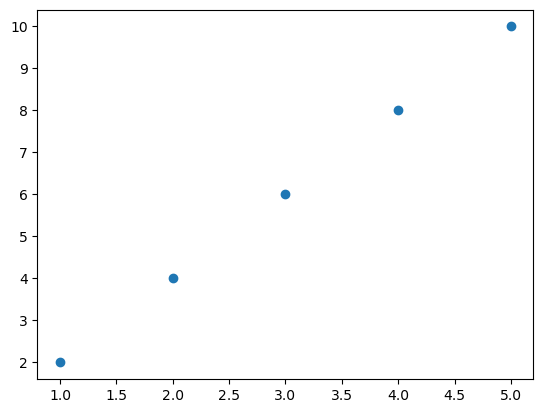

In [4]:
plt.scatter(x,y)

In [5]:
x_new = np.linspace(1,5,10)

In [8]:
y_interp =np.interp(x_new, x ,y)

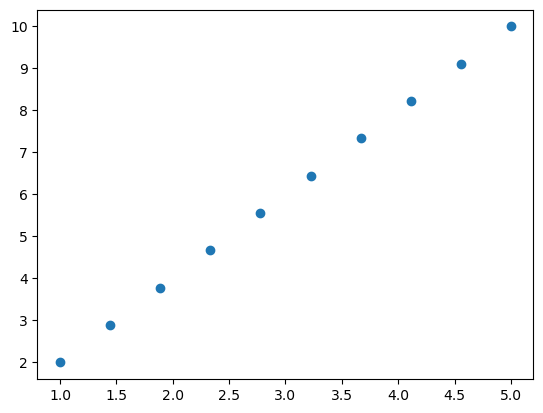

In [9]:
plt.scatter(x_new, y_interp)

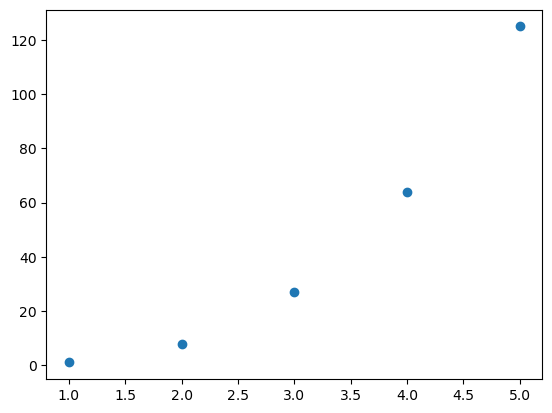

In [10]:
#cubic interpolation

x =np.array([1,2,3,4,5])
y = np.array([1,8,27,64,125])

plt.scatter(x,y)

In [11]:
from scipy.interpolate import interp1d

In [12]:
f =interp1d(x,y, kind ='cubic')

In [13]:
x_new = np.linspace(1,5,10)
y_inter = f(x_new)

In [15]:
y_interp

array([ 2.        ,  2.88888889,  3.77777778,  4.66666667,  5.55555556,
        6.44444444,  7.33333333,  8.22222222,  9.11111111, 10.        ])

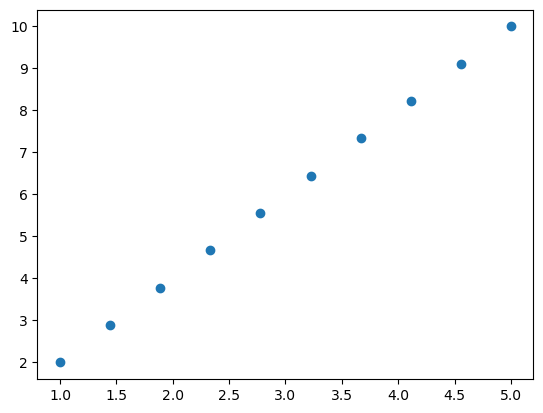

In [16]:
plt.scatter(x_new,y_interp)

In [17]:
#polynomial interpolation

x = np.array([1,2,3,4,5])
y = np.array([1,4,9,1,25])

In [19]:
#interpolate using poinomial interpolation
p =np.polyfit(x,y,2)

In [20]:
x_new = np.linspace(1,5,10)
y_interp = np.polyval(p, x_new)

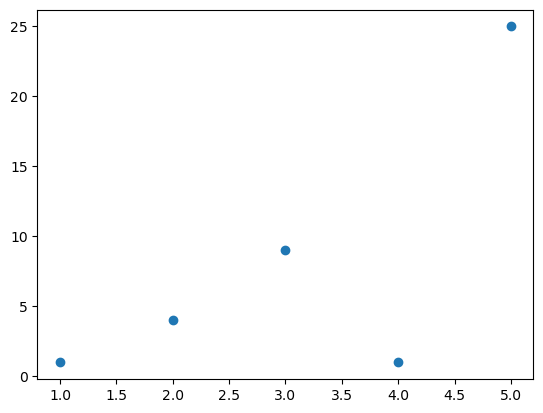

In [22]:
plt.scatter(x,y)

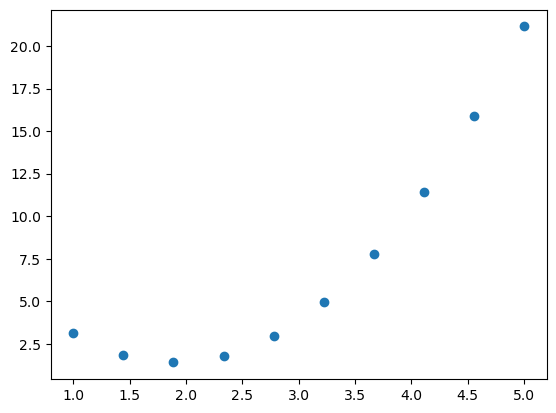

In [23]:
plt.scatter(x_new,y_interp)

In [24]:
# use cases >> missing data, generation data of new point

In [60]:
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

salary = [11,40,45,68,65,68,78,90,57,74,91,92,88,68,57,48,99,101,68,77,110,140]

In [28]:
#extreme value are outliers

In [29]:
#five point summary
#min>25 , 50,75,100 
np.quantile(salary,[0,0.25,.50,.75,.1])

array([11.  , 59.  , 71.  , 90.75, 45.3 ])

In [61]:
df = pd.DataFrame(salary, columns = ['salary'])

In [33]:
df.describe()

,salary
count,22.000000
mean,74.318182
std,27.201867
min,11.000000
25%,59.000000
50%,71.000000
75%,90.750000
max,140.000000


In [34]:
# to check outlier >> distplot , boxplot

Text(0.5, 1.0, 'Box plot')

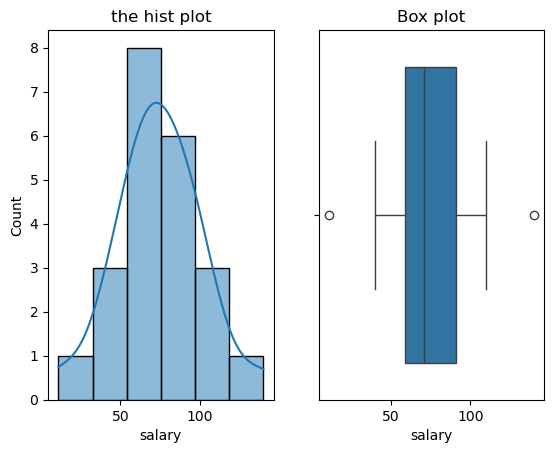

In [39]:
plt.Figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['salary'], kde = True)
plt.title("the hist plot")

plt.subplot(1,2,2)
sns.boxplot(data = df, x ='salary')
plt.title("Box plot")

In [40]:
#dropping outlier
#caping the outlier
#replace wuth mean median

In [63]:
#drop outlier
q1 = df['salary'].quantile(0.25)
q3 = df['salary'].quantile(0.75)

iqr = q3 -q1
lower_fence = q1 - 1.5*iqr
upper_fence = q3+1.5 * iqr

In [42]:
lower_fence

np.float64(11.375)

In [43]:
upper_fence

np.float64(138.375)

In [64]:
df_filtered =df[(df.salary >= lower_fence) & (df.salary <= upper_fence)]

In [51]:
df_filtered.shape

(20, 1)

In [52]:
df.shape

(22, 1)

Text(0.5, 1.0, 'Box plot')

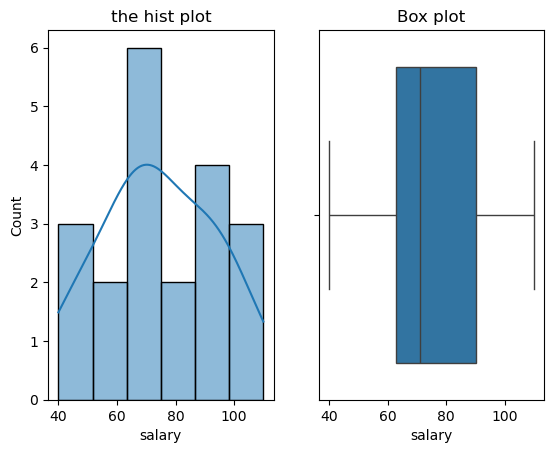

In [54]:
plt.Figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_filtered['salary'], kde = True)
plt.title("the hist plot")

plt.subplot(1,2,2)
sns.boxplot(data = df_filtered, x ='salary')
plt.title("Box plot")

In [75]:
#imputation with mean and median
df['salary_imputed_mean']= np.where((df.salary >= upper_fence) | (df.salary <= lower_fence), df['salary'].mean(), df['salary'])

In [56]:
df

,salary,salary_imputed_mean
0,11,74.318182
1,40,40.000000
2,45,45.000000
3,68,68.000000
4,65,65.000000
5,68,68.000000
6,78,78.000000
7,90,90.000000
8,57,57.000000
9,74,74.000000


Text(0.5, 1.0, 'Box plot of salary')

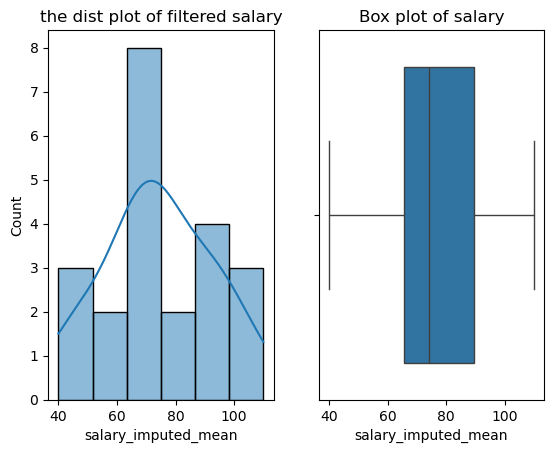

In [57]:
plt.Figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['salary_imputed_mean'], kde = True)
plt.title("the dist plot of filtered salary")

plt.subplot(1,2,2)
sns.boxplot(data = df, x ='salary_imputed_mean')
plt.title("Box plot of salary")

In [74]:
df['salary_imputed_median']= np.where((df.salary >= upper_fence) | (df.salary <= lower_fence), df['salary'].median(), df['salary'])

Text(0.5, 1.0, 'Box plot of salary')

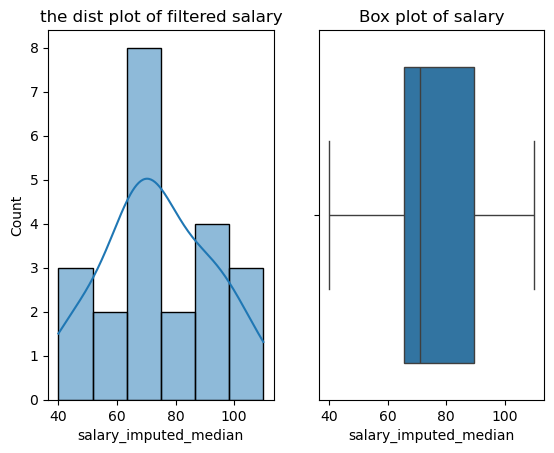

In [76]:
plt.Figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['salary_imputed_median'], kde = True)
plt.title("the dist plot of filtered salary")

plt.subplot(1,2,2)
sns.boxplot(data = df, x ='salary_imputed_median')
plt.title("Box plot of salary")

In [77]:
df

,salary,salary_imputed_mean,salary_imputed_median
0,11,74.318182,71.0
1,40,40.000000,40.0
2,45,45.000000,45.0
3,68,68.000000,68.0
4,65,65.000000,65.0
5,68,68.000000,68.0
6,78,78.000000,78.0
7,90,90.000000,90.0
8,57,57.000000,57.0
9,74,74.000000,74.0


In [78]:
lower_cap = df['salary'].quantile(0.05)  #lower cap as 5th percentile

In [80]:
upper_cap = df['salary'].quantile(.95)#upper cap at 95th percentile

lower_cap

np.float64(40.25)

In [81]:
upper_cap

np.float64(109.55)

In [83]:
#replace outlier wih upper_cap

df['salary_capped'] =np.where(df['salary'] < lower_cap, lower_cap,
         np.where(df['salary'] >  upper_cap, upper_cap, df['salary']))

In [84]:
df

,salary,salary_imputed_mean,salary_imputed_median,salary_capped
0,11,74.318182,71.0,40.25
1,40,40.000000,40.0,40.25
2,45,45.000000,45.0,45.00
3,68,68.000000,68.0,68.00
4,65,65.000000,65.0,65.00
5,68,68.000000,68.0,68.00
6,78,78.000000,78.0,78.00
7,90,90.000000,90.0,90.00
8,57,57.000000,57.0,57.00
9,74,74.000000,74.0,74.00


Text(0.5, 1.0, 'Box plot of capped salary')

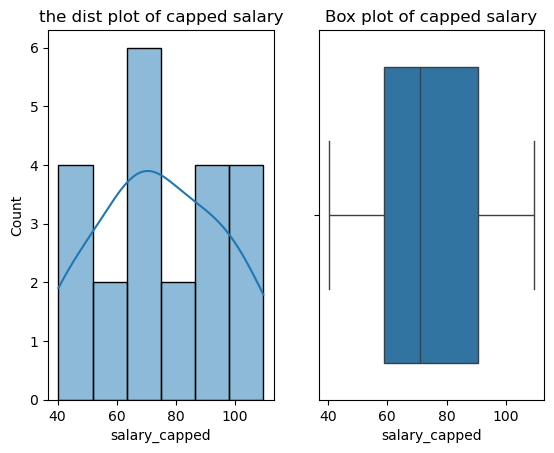

In [85]:
plt.Figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['salary_capped'], kde = True)
plt.title("the dist plot of capped salary")

plt.subplot(1,2,2)
sns.boxplot(data = df, x ='salary_capped')
plt.title("Box plot of capped salary")